Exercise 05.01: Loading the dataset

In [24]:
import pandas as pd

starwars_df = pd.read_csv('starwars.csv')

In [25]:
print(starwars_df.head())

             name  height   mass hair_color   skin_color eye_color  \
0  Luke Skywalker   172.0   77.0      blond         fair      blue   
1           C-3PO   167.0   75.0        NaN         gold    yellow   
2           R2-D2    96.0   32.0        NaN  white, blue       red   
3     Darth Vader   202.0  136.0       none        white    yellow   
4     Leia Organa   150.0   49.0      brown        light     brown   

   birth_year     sex     gender homeworld species  \
0        19.0    male  masculine  Tatooine   Human   
1       112.0    none  masculine  Tatooine   Droid   
2        33.0    none  masculine     Naboo   Droid   
3        41.9    male  masculine  Tatooine   Human   
4        19.0  female   feminine  Alderaan   Human   

                                               films  \
0  A New Hope, The Empire Strikes Back, Return of...   
1  A New Hope, The Empire Strikes Back, Return of...   
2  A New Hope, The Empire Strikes Back, Return of...   
3  A New Hope, The Empire Stri

In [26]:
print(starwars_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        87 non-null     object 
 1   height      81 non-null     float64
 2   mass        59 non-null     float64
 3   hair_color  82 non-null     object 
 4   skin_color  87 non-null     object 
 5   eye_color   87 non-null     object 
 6   birth_year  43 non-null     float64
 7   sex         83 non-null     object 
 8   gender      83 non-null     object 
 9   homeworld   77 non-null     object 
 10  species     83 non-null     object 
 11  films       87 non-null     object 
 12  vehicles    11 non-null     object 
 13  starships   20 non-null     object 
dtypes: float64(3), object(11)
memory usage: 9.6+ KB
None


## Question 1: What is the size of the dataset (number of rows and columns)?

With the call on ".info()", we can see that the dataset has 87 rows and 14 columns.

## Question 2: Which columns contain missing values?

Here we also already have the information about the amount of non-null entries in the columns. In the next cell we can specifically see the amount of null values per column.

In [ ]:
starwars_df.isna().sum()

<Axes: >

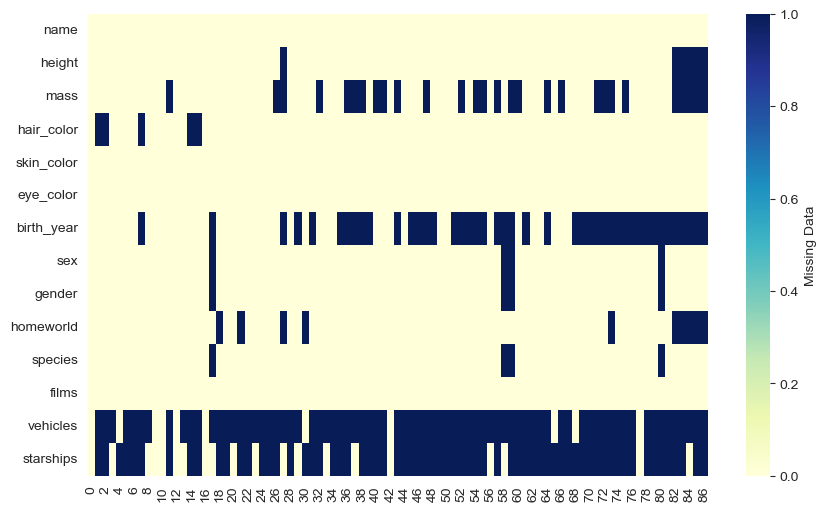

In [28]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(starwars_df.isna().transpose(),
            cmap="YlGnBu",
            cbar_kws={'label': 'Missing Data'})



This plot shows the distribution of the null values in the dataset. Here you can see, that there are multiple rows missing data on the columns "vehicles", "starships" and "birth_year".

In [29]:
starwars_df.iloc[:, 6]

0      19.0
1     112.0
2      33.0
3      41.9
4      19.0
      ...  
82      NaN
83      NaN
84      NaN
85      NaN
86      NaN
Name: birth_year, Length: 87, dtype: float64

In [30]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy="mean")
starwars_df.iloc[:, 1:3] = mean_imputer.fit_transform(
    starwars_df[["height", "mass"]]
)
starwars_df.iloc[:, 6] = mean_imputer.fit_transform(starwars_df[["birth_year"]])

## Question 3: How did you handle the missing values, and what changes were made to the dataset as a result?

We substituted the null values in the columns "height", "mass" and "birth_year" with the mean by using the SimpleImputer. We chose the strategy "mean", since the values of these columns are all numerical and by using the mean the data won't be skewed. A different option would be removing the rows. But since it would affect so many rows, this would be the last option to chose.

In [31]:
starwars_df

,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
0,Luke Skywalker,172.000000,77.000000,blond,fair,blue,19.000000,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...","Snowspeeder, Imperial Speeder Bike","X-wing, Imperial shuttle"
1,C-3PO,167.000000,75.000000,NaN,gold,yellow,112.000000,none,masculine,Tatooine,Droid,"A New Hope, The Empire Strikes Back, Return of...",NaN,NaN
2,R2-D2,96.000000,32.000000,NaN,"white, blue",red,33.000000,none,masculine,Naboo,Droid,"A New Hope, The Empire Strikes Back, Return of...",NaN,NaN
3,Darth Vader,202.000000,136.000000,none,white,yellow,41.900000,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...",NaN,TIE Advanced x1
4,Leia Organa,150.000000,49.000000,brown,light,brown,19.000000,female,feminine,Alderaan,Human,"A New Hope, The Empire Strikes Back, Return of...",Imperial Speeder Bike,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,Finn,174.604938,97.311864,black,dark,dark,87.565116,male,masculine,NaN,Human,The Force Awakens,NaN,NaN
83,Rey,174.604938,97.311864,brown,light,hazel,87.565116,female,feminine,NaN,Human,The Force Awakens,NaN,NaN
84,Poe Dameron,174.604938,97.311864,brown,light,brown,87.565116,male,masculine,NaN,Human,The Force Awakens,NaN,X-wing
85,BB8,174.604938,97.311864,none,none,black,87.565116,none,masculine,NaN,Droid,The Force Awakens,NaN,NaN


In [32]:
starwars_df.fillna("Unknown", inplace=True)

## Part of Answer to Question 3

Here we fill all remaining null values with "Unknown", because the columns with null values have string values.

In [35]:
starwars_df

,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
0,Luke Skywalker,172.000000,77.000000,blond,fair,blue,19.000000,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...","Snowspeeder, Imperial Speeder Bike","X-wing, Imperial shuttle"
1,C-3PO,167.000000,75.000000,Unknown,gold,yellow,112.000000,none,masculine,Tatooine,Droid,"A New Hope, The Empire Strikes Back, Return of...",Unknown,Unknown
2,R2-D2,96.000000,32.000000,Unknown,"white, blue",red,33.000000,none,masculine,Naboo,Droid,"A New Hope, The Empire Strikes Back, Return of...",Unknown,Unknown
3,Darth Vader,202.000000,136.000000,none,white,yellow,41.900000,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...",Unknown,TIE Advanced x1
4,Leia Organa,150.000000,49.000000,brown,light,brown,19.000000,female,feminine,Alderaan,Human,"A New Hope, The Empire Strikes Back, Return of...",Imperial Speeder Bike,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,Finn,174.604938,97.311864,black,dark,dark,87.565116,male,masculine,Unknown,Human,The Force Awakens,Unknown,Unknown
83,Rey,174.604938,97.311864,brown,light,hazel,87.565116,female,feminine,Unknown,Human,The Force Awakens,Unknown,Unknown
84,Poe Dameron,174.604938,97.311864,brown,light,brown,87.565116,male,masculine,Unknown,Human,The Force Awakens,Unknown,X-wing
85,BB8,174.604938,97.311864,none,none,black,87.565116,none,masculine,Unknown,Droid,The Force Awakens,Unknown,Unknown


In [36]:
starwars_df.isna().sum()

name          0
height        0
mass          0
hair_color    0
skin_color    0
eye_color     0
birth_year    0
sex           0
gender        0
homeworld     0
species       0
films         0
vehicles      0
starships     0
dtype: int64

## Question 4: Provide a preview of the first and the last 10 rows of the updated dataset after handling missing data.

In [42]:
starwars_df.iloc[0:11, :]

,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
0,Luke Skywalker,172.0,77.0,blond,fair,blue,19.000000,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...","Snowspeeder, Imperial Speeder Bike","X-wing, Imperial shuttle"
1,C-3PO,167.0,75.0,Unknown,gold,yellow,112.000000,none,masculine,Tatooine,Droid,"A New Hope, The Empire Strikes Back, Return of...",Unknown,Unknown
2,R2-D2,96.0,32.0,Unknown,"white, blue",red,33.000000,none,masculine,Naboo,Droid,"A New Hope, The Empire Strikes Back, Return of...",Unknown,Unknown
3,Darth Vader,202.0,136.0,none,white,yellow,41.900000,male,masculine,Tatooine,Human,"A New Hope, The Empire Strikes Back, Return of...",Unknown,TIE Advanced x1
4,Leia Organa,150.0,49.0,brown,light,brown,19.000000,female,feminine,Alderaan,Human,"A New Hope, The Empire Strikes Back, Return of...",Imperial Speeder Bike,Unknown
5,Owen Lars,178.0,120.0,"brown, grey",light,blue,52.000000,male,masculine,Tatooine,Human,"A New Hope, Attack of the Clones, Revenge of t...",Unknown,Unknown
6,Beru Whitesun Lars,165.0,75.0,brown,light,blue,47.000000,female,feminine,Tatooine,Human,"A New Hope, Attack of the Clones, Revenge of t...",Unknown,Unknown
7,R5-D4,97.0,32.0,Unknown,"white, red",red,87.565116,none,masculine,Tatooine,Droid,A New Hope,Unknown,Unknown
8,Biggs Darklighter,183.0,84.0,black,light,brown,24.000000,male,masculine,Tatooine,Human,A New Hope,Unknown,X-wing
9,Obi-Wan Kenobi,182.0,77.0,"auburn, white",fair,blue-gray,57.000000,male,masculine,Stewjon,Human,"A New Hope, The Empire Strikes Back, Return of...",Tribubble bongo,"Jedi starfighter, Trade Federation cruiser, Na..."


In [43]:
starwars_df.iloc[-11:, :]

,name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species,films,vehicles,starships
76,Shaak Ti,178.000000,57.000000,none,"red, blue, white",black,87.565116,female,feminine,Shili,Togruta,"Attack of the Clones, Revenge of the Sith",Unknown,Unknown
77,Grievous,216.000000,159.000000,none,"brown, white","green, yellow",87.565116,male,masculine,Kalee,Kaleesh,Revenge of the Sith,Tsmeu-6 personal wheel bike,Belbullab-22 starfighter
78,Tarfful,234.000000,136.000000,brown,brown,blue,87.565116,male,masculine,Kashyyyk,Wookiee,Revenge of the Sith,Unknown,Unknown
79,Raymus Antilles,188.000000,79.000000,brown,light,brown,87.565116,male,masculine,Alderaan,Human,"A New Hope, Revenge of the Sith",Unknown,Unknown
80,Sly Moore,178.000000,48.000000,none,pale,white,87.565116,Unknown,Unknown,Umbara,Unknown,"Attack of the Clones, Revenge of the Sith",Unknown,Unknown
81,Tion Medon,206.000000,80.000000,none,grey,black,87.565116,male,masculine,Utapau,Pau'an,Revenge of the Sith,Unknown,Unknown
82,Finn,174.604938,97.311864,black,dark,dark,87.565116,male,masculine,Unknown,Human,The Force Awakens,Unknown,Unknown
83,Rey,174.604938,97.311864,brown,light,hazel,87.565116,female,feminine,Unknown,Human,The Force Awakens,Unknown,Unknown
84,Poe Dameron,174.604938,97.311864,brown,light,brown,87.565116,male,masculine,Unknown,Human,The Force Awakens,Unknown,X-wing
85,BB8,174.604938,97.311864,none,none,black,87.565116,none,masculine,Unknown,Droid,The Force Awakens,Unknown,Unknown
